<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/4_Aprendizaje_no_supervisado/3_Taller_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller: Creación de un Índice de Clima de Inversión con Análisis de Componentes Principales (PCA)**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

- Samuel David Huertas Infante
- Juan Diego Villabón López


**Forma de entrega:**

- Nombrar el archivo de la siguiente forma:“Taller_PCA_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/q1ZSe3N80C.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

28 de abril de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

### Contexto

**Escenario:** Eres un científico de datos recién contratado como consultor experto por el **Ministerio de Comercio, Industria y Turismo (MinCIT)** de Colombia. Tu tarea principal es crear un **'Índice de Clima para la Inversión'** cuantitativo que permita clasificar y comparar el entorno competitivo de los países de América Latina y el Caribe. Este índice orientará las estrategias de integración regional y las políticas para atraer Inversión Extranjera Directa (IED).

**Objetivo:** Utilizando la base de datos de indicadores provista (preparada para este análisis) y la técnica de **Análisis de Componentes Principales (PCA)**, deberás extraer la "variable latente" que resume el clima de inversión, interpretar sus pesos económicos y presentar un ranking de países con recomendaciones ejecutivas.


## Ejercicio 1: Configuración Inicial, Carga y Exploración de Datos

1.1 Importa las librerías necesarias

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
# Configuraciones de visualización
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

1.2 Carga el dataset "Indicators.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_indicators".

In [5]:
from google.colab import drive, files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_indicators = pd.read_csv('/content/drive/MyDrive/2026-i-curso-ia-para-economia/datasets/Indicators.csv', header=0)

In [32]:
# Debe ser (121, 4)
print("Dimensiones del DataFrame Indicators:")
print(df_indicators.shape)

Dimensiones del DataFrame Indicators:
(121, 4)


In [9]:
print("\nInformación general del DataFrame:")
df_indicators.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CountryCode    121 non-null    object 
 1   IndicatorCode  121 non-null    object 
 2   Year           121 non-null    int64  
 3   Value          121 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.9+ KB


1.3 Carga el dataset "Country.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_countries".

In [10]:
df_countries = pd.read_csv('/content/drive/MyDrive/2026-i-curso-ia-para-economia/datasets/Country.csv', header=0)

In [11]:
# Debe ser (14, 3)
print("Dimensiones del DataFrame Countries:")
print(df_countries.shape)

Dimensiones del DataFrame Countries:
(14, 3)


In [12]:
print("\nInformación general del DataFrame:")
df_countries.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CountryCode  14 non-null     object
 1   ShortName    14 non-null     object
 2   Region       14 non-null     object
dtypes: object(3)
memory usage: 468.0+ bytes


### Ejercicio 2: Selección y Preparación de Datos

Para el análisis del MinCIT, hemos preseleccionado un conjunto de variables clave.

2.1. Utiliza el diccionario para modificar los códigos de los indicadores por sus descripciones

In [13]:
nombre_indicadores = {
    'NV.AGR.TOTL.ZS': 'Agricultura (% del PIB)',
    'NE.TRD.GNFS.ZS': 'Comercio (% del PIB)',
    'NY.GDP.MKTP.KD.ZG': 'Crecimiento del PIB (%)',
    'FP.CPI.TOTL.ZG': 'Inflación (%)',
    'GC.DOD.TOTL.GD.ZS': 'Deuda del gob. central (% del PIB)',
    'SE.XPD.TOTL.GD.ZS': 'Gasto en educación (% del PIB)',
    'SH.XPD.CHEX.GD.ZS': 'Gasto en salud (% del PIB)',
    'IQ.CPA.BREG.XQ': 'Facilidad para hacer negocios',
    'IC.LGL.DURS': 'Días para cumplir contratos',
    'TX.VAL.MRCH.XD.WD': 'Exportaciones (US$)',
    'TM.VAL.MRCH.XD.WD': 'Importaciones (US$)'
}

In [15]:
df_indicators['IndicatorCode'] = df_indicators['IndicatorCode'].map(nombre_indicadores)


2.2. Utiliza pivot table para crear un nuevo dataframe donde se encuentren los países como filas y los indicadores como columnas. Llama a este dataframe "df_pivot". No olvides colocar .reset_index() para que la columna de código de países quede como una columna y no como el índice.

In [23]:
df_pivot = df_indicators.pivot_table(index='CountryCode', columns='IndicatorCode', values='Value').reset_index()

df_pivot.head()

IndicatorCode,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
0,ARG,11.729809,32.425764,-0.446515,73.070469,873.484277,2.015373e+10,2.192659,2.377131,4.086590,1.805821e+10,44.281994
1,BOL,NaN,54.393368,1.760405,66.689800,798.964110,3.903698e+10,NaN,5.367211,5.046883,3.697718e+10,36.046910
2,BRA,12.785683,60.181680,2.585309,57.195313,741.683654,5.604386e+10,3.571627,4.555868,5.307244,5.002645e+10,25.602741
3,CHL,6.745071,74.308678,7.647689,42.829233,535.915768,9.054256e+10,5.883717,6.382932,8.289606,8.053658e+10,12.615149
4,COL,6.922377,59.959234,6.599647,47.948083,633.896842,NaN,NaN,6.339858,6.300896,6.742420e+10,11.611339


2.3. Crea el dataframe "df_final", realizando un merge entre "df_pivot" y "df_countries" con el fin de agregar el nombre de los países.

In [24]:
df_final = df_pivot.merge(df_countries, on='CountryCode', how='left')

df_final.head()

,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),ShortName,Region
0,ARG,11.729809,32.425764,-0.446515,73.070469,873.484277,2.015373e+10,2.192659,2.377131,4.086590,1.805821e+10,44.281994,Argentina,Latin America & Caribbean
1,BOL,NaN,54.393368,1.760405,66.689800,798.964110,3.903698e+10,NaN,5.367211,5.046883,3.697718e+10,36.046910,Bolivia,Latin America & Caribbean
2,BRA,12.785683,60.181680,2.585309,57.195313,741.683654,5.604386e+10,3.571627,4.555868,5.307244,5.002645e+10,25.602741,Brasil,Latin America & Caribbean
3,CHL,6.745071,74.308678,7.647689,42.829233,535.915768,9.054256e+10,5.883717,6.382932,8.289606,8.053658e+10,12.615149,Chile,Latin America & Caribbean
4,COL,6.922377,59.959234,6.599647,47.948083,633.896842,NaN,NaN,6.339858,6.300896,6.742420e+10,11.611339,Colombia,Latin America & Caribbean


2.4. Elimina las columnas "Region" y "CountryCode" y establece la columna 'ShortName' como el índice del dataframe

In [25]:
df_final = df_final.drop(columns=['Region', 'CountryCode'])
df_final = df_final.set_index('ShortName')

df_final.head()

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
ShortName,,,,,,,,,,,
Argentina,11.729809,32.425764,-0.446515,73.070469,873.484277,2.015373e+10,2.192659,2.377131,4.086590,1.805821e+10,44.281994
Bolivia,NaN,54.393368,1.760405,66.689800,798.964110,3.903698e+10,NaN,5.367211,5.046883,3.697718e+10,36.046910
Brasil,12.785683,60.181680,2.585309,57.195313,741.683654,5.604386e+10,3.571627,4.555868,5.307244,5.002645e+10,25.602741
Chile,6.745071,74.308678,7.647689,42.829233,535.915768,9.054256e+10,5.883717,6.382932,8.289606,8.053658e+10,12.615149
Colombia,6.922377,59.959234,6.599647,47.948083,633.896842,NaN,NaN,6.339858,6.300896,6.742420e+10,11.611339


### Ejercicio 3: Limpieza de Datos (Imputación de Valores Faltantes)

En la vida real de un economista, los datos tienen huecos. El PCA requiere bases completas. Usaremos una estrategia de imputación por la media para resolver los NaN.

3.1. Revisa cuántos valores faltantes hay en cada columna

In [30]:
df_final.isnull().sum()

,0
Agricultura (% del PIB),4
Comercio (% del PIB),3
Crecimiento del PIB (%),0
Deuda del gob. central (% del PIB),4
Días para cumplir contratos,2
Exportaciones (US$),3
Facilidad para hacer negocios,5
Gasto en educación (% del PIB),3
Gasto en salud (% del PIB),4
Importaciones (US$),3


3.2. Para cada columna, utiliza el promedio del resto de países de Latinoamérica para imputar los valores faltantes. El resultado debe quedar en un dataframe llamado "df_final_imputed". Al final revisa que no haya quedado ningún valor faltante en las columnas del dataframe.

In [35]:
latam_countries = df_countries.loc[df_countries['Region'] == 'Latin America', 'ShortName']

latam_means = df_final.loc[df_final.index.isin(latam_countries)].mean(numeric_only=True)

df_final_imputed = df_final_imputed.fillna(df_final.mean(numeric_only=True))

print(df_final_imputed.isnull().sum())

Agricultura (% del PIB)               0
Comercio (% del PIB)                  0
Crecimiento del PIB (%)               0
Deuda del gob. central (% del PIB)    0
Días para cumplir contratos           0
Exportaciones (US$)                   0
Facilidad para hacer negocios         0
Gasto en educación (% del PIB)        0
Gasto en salud (% del PIB)            0
Importaciones (US$)                   0
Inflación (%)                         0
dtype: int64


### Ejercicio 4: Matriz de Correlaciones y Estandarización de Variables

4.1. Grafica un mapa de calor para ver las correlaciones entre las variables.

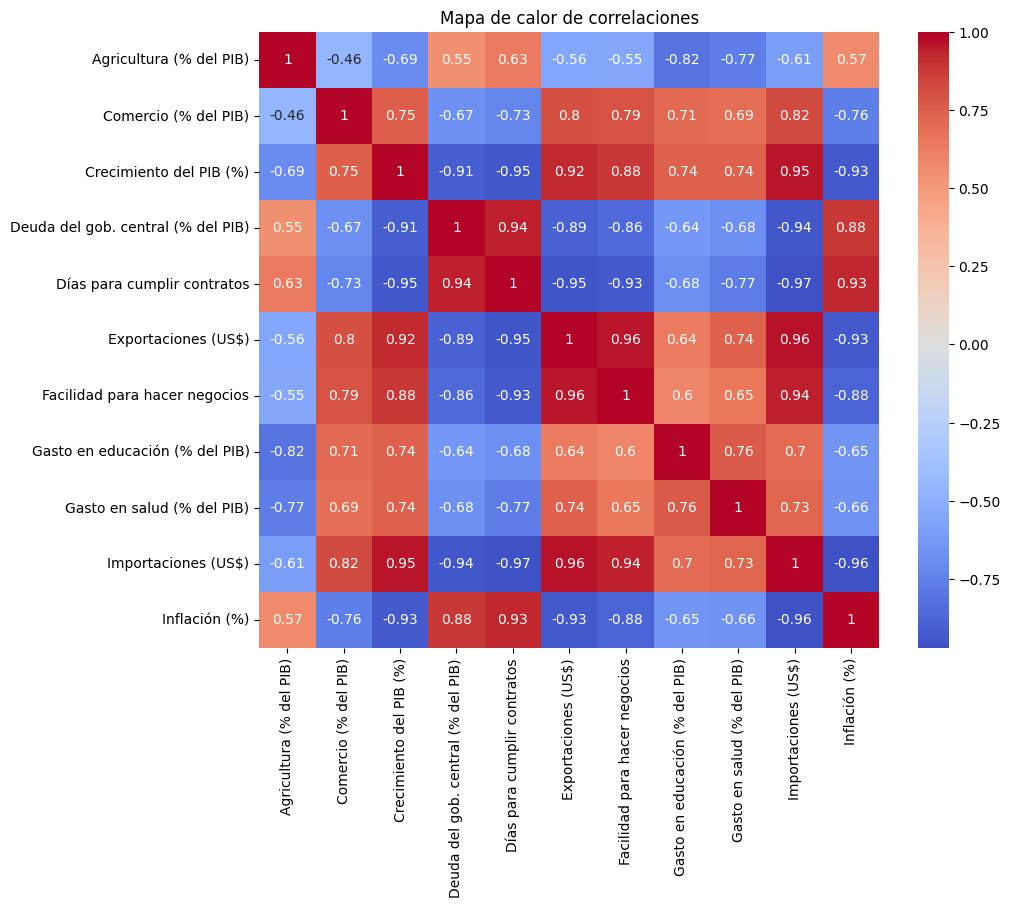

In [36]:
corr_matrix = df_final_imputed.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Mapa de calor de correlaciones")
plt.show()

4.2. Interpreta los resultados resaltando las correlaciones más relevantes.

El crecimiento del PIB está muy correlacionado a las importaciones y exportaciones, mientras que se relaciona de forma negativa con la deuda pública y las variables institucionales como facilidad para hacer negocios y días para cumplir contratos se mueven juntas, y las sociales como gasto en educación y salud también, mientras que la agricultura no tiene gran relación con los otros indicadores.

4.3. Las exportaciones están en miles de millones de dólares y el crecimiento en porcentajes de un dígito. PCA busca varianzas, por lo que estandarizar (Media 0, Desviación 1) es un paso matemático obligatorio para no sesgar el modelo hacia las variables nominales grandes.  Estandariza todas las variables del dataframe y almacena el resultado en X_scaled.

In [41]:
X = df_final_imputed.select_dtypes(include='number')

X_scaled = X - X.mean()

X_scaled.head()

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
ShortName,,,,,,,,,,,
Argentina,2.871131e+00,-23.650472,-4.035339,14.319881,173.209219,-3.637336e+10,-1.770185e+00,-2.790967,-2.158287,-3.360953e+10,21.694996
Bolivia,-1.776357e-15,-1.682869,-1.828418,7.939212,98.689052,-1.749010e+10,4.440892e-16,0.199113,-1.197995,-1.469056e+10,13.459912
Brasil,3.927005e+00,4.105444,-1.003515,-1.555275,41.408596,-4.832264e+08,-3.912157e-01,-0.612230,-0.937634,-1.641293e+09,3.015743
Chile,-2.113607e+00,18.232442,4.058865,-15.921355,-164.359290,3.401547e+10,1.920874e+00,1.214834,2.044729,2.886884e+10,-9.971849
Colombia,-1.936302e+00,3.882997,3.010823,-10.802505,-66.378216,7.629395e-06,4.440892e-16,1.171761,0.056018,1.575646e+10,-10.975659


### Ejercicio 5: Aplicación de PCA

Vamos a correr PCA para identificar el número de componentes. Buscamos capturar la mayor cantidad de información (varianza) con la menor cantidad de dimensiones.

5.1. Corre PCA sobre X_scaled y calcula la varianza acumulada. Almacénala en la variable "varianza_acumulada".

In [49]:
pca_simple = PCA()
pca_simple.fit(X_scaled)

varianza_acumulada = pca_simple.explained_variance_ratio_.cumsum()
print(varianza_acumulada)


[0.98103282 1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.        ]


5.2. Similar a como lo vimos en clase, grafica la varianza explicada acumulada por componente.

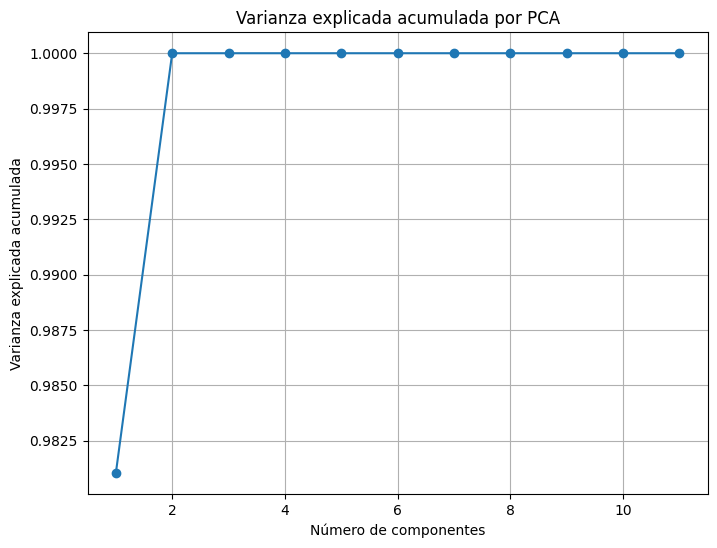

In [50]:
plt.figure(figsize=(8,6))
plt.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada por PCA')
plt.grid(True)
plt.show()

5.3. Realiza un análisis del gráfico anterior.

Casi toda la variabilidad de los datos se explica con los dos primeros componentes, ya que la curva sube rapido al inicio y luego se mantiene plana lo que significa que con solo esos componentes se conserva la información relevante, y los otros aportan muy poco valor.

### Ejercicio 6: Interpretación Económica de los Componentes (Loadings)

Nos vamos a quedar con un solo componente. Vamor a analizar qué variables originales alimentan a este componente.

6.1. Corre nuevamente el PCA, pero ahora indicando que tenga en cuenta solo 1 componente. Almacena el modelo en "pca_final" y los resultados en "X_pca".

In [51]:
pca_final = PCA(n_components=1)
X_pca = pca_final.fit_transform(X_scaled)

6.2. Grafica el mapa de calor de los loadings como lo vimos en clase

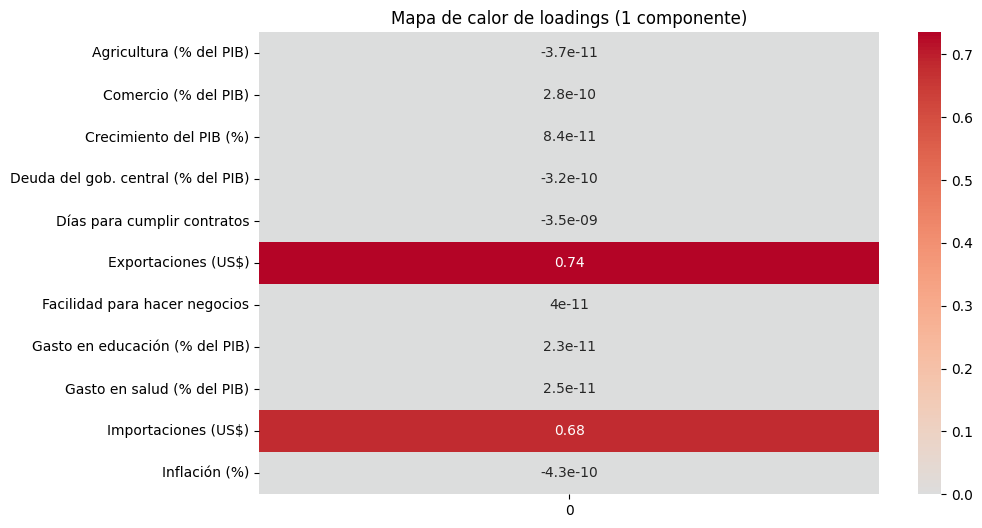

In [52]:
loadings = pd.DataFrame(pca_final.components_, columns=X_scaled.columns)

plt.figure(figsize=(10,6))
sns.heatmap(loadings.T, annot=True, cmap='coolwarm', center=0)
plt.title('Mapa de calor de loadings (1 componente)')
plt.show()

6.3. Realiza una interpretación de los loadings. ¿Cuáles variables tienen las cargas altas y positivas y cuáles las cargas altas y negativas? De acuerdo con este análisis, ¿consideras que efectivamente podemos utilizar el componente 1 como un índice del clima para la inversión en cada país de Latinoamérica? ¿por qué si o por qué no?

Los loadings muestran que el primer componente esta dominado por las exportaciones y las importaciones, que tienen cargas altas y positivas, mientras que el resto de variables apenas aportan o lo hacen con valores muy cercanos a cero; esto significa que el componente refleja principalmente la apertura comercial de los paises, por lo que si puede usarse como un indice del clima de inversion en Latinoamérica.


### Ejercicio 7: Creación del 'Índice de Clima para la Inversión'

Asignaremos el CP1 como nuestro 'Índice de Clima para la Inversión' y construiremos el ranking regional.

In [53]:
df_final['Indice_Inversion'] = X_pca[:, 0]
df_final.head()

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),Indice_Inversion
ShortName,,,,,,,,,,,,
Argentina,11.729809,32.425764,-0.446515,73.070469,873.484277,2.015373e+10,2.192659,2.377131,4.086590,1.805821e+10,44.281994,-4.952394e+10
Bolivia,NaN,54.393368,1.760405,66.689800,798.964110,3.903698e+10,NaN,5.367211,5.046883,3.697718e+10,36.046910,-2.281648e+10
Brasil,12.785683,60.181680,2.585309,57.195313,741.683654,5.604386e+10,3.571627,4.555868,5.307244,5.002645e+10,25.602741,-1.468022e+09
Chile,6.745071,74.308678,7.647689,42.829233,535.915768,9.054256e+10,5.883717,6.382932,8.289606,8.053658e+10,12.615149,4.457650e+10
Colombia,6.922377,59.959234,6.599647,47.948083,633.896842,NaN,NaN,6.339858,6.300896,6.742420e+10,11.611339,1.068320e+10


7.1. Ordena el df_final por el índice de clima para la inversión de mayor a menor valor del índice.

In [54]:
pca_final = PCA(n_components=1)
X_pca = pca_final.fit_transform(X_scaled)

ranking = pd.DataFrame({
    'ShortName': df_final.index,
    'Indice_Clima_Inversion': X_pca.flatten()
}).sort_values(by='Indice_Clima_Inversion', ascending=False).reset_index(drop=True)

7.2. Convierte 'ShortName' en una columna del dataframe.

In [55]:
ranking = ranking.reset_index(drop=True)

ranking.head()

,ShortName,Indice_Clima_Inversion
0,Chile,4.457650e+10
1,Panamá,3.690504e+10
2,Costa Rica,2.996311e+10
3,México,1.111909e+10
4,Colombia,1.068320e+10


7.3. Utiliza un barplot para mostrar los resultados del Índice de Clima para la Inversión. En el eje y deben ir los países y en el eje X el puntaje del índice. No olvides colocar título al gráfico y a los ejes.

/tmp/ipykernel_10171/3556005376.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ranking, x='Indice_Clima_Inversion', y='ShortName', palette='viridis')


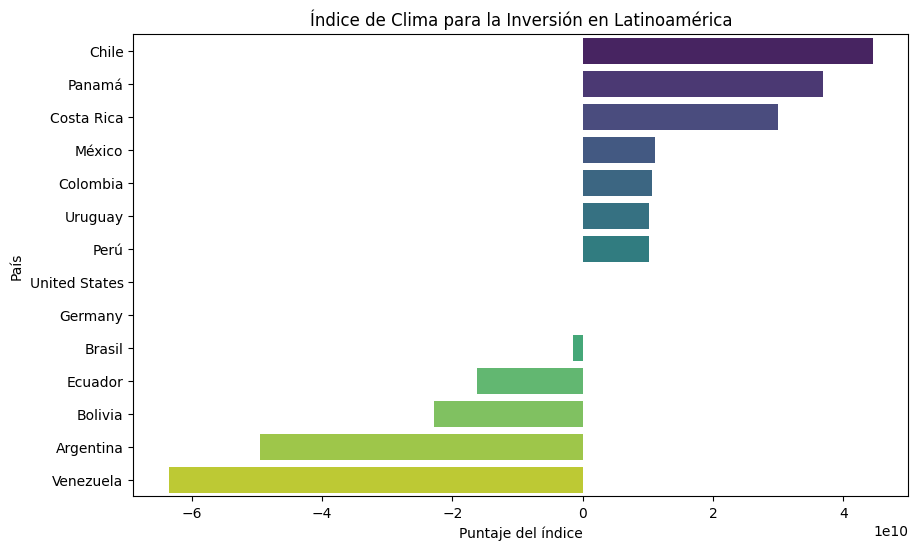

In [56]:
plt.figure(figsize=(10,6))
sns.barplot(data=ranking, x='Indice_Clima_Inversion', y='ShortName', palette='viridis')
plt.title('Índice de Clima para la Inversión en Latinoamérica')
plt.xlabel('Puntaje del índice')
plt.ylabel('País')
plt.show()

7.4. Analiza los resultados del gráfico y redacta una conclusiones para el MinCIT sobre el clima de inversión en la región, quiénes son nuestros competidores en la atracción de capitales extranjeros y por qué, en qué son mejores que Colombia.

El grafico muestra que Chile, Panamá y Costa Rica lideran el índice de clima para la inversión, lo que refleja su mayor apertura comercial y estabilidad, mientras que Venezuela y Argentina aparecen al final con condiciones menos favorables; en este contexto, Colombia se ubica en la mitad del ranking y sus principales competidores en atracción de capital extranjero son los países que lo superan, porque ofrecen mayor dinamismo económico y confianza institucional, factores que los hacen más atractivos para los inversionistas.